# CMAPSS FD001 — Exploratory Data Analysis

## Objectives
- Understand dataset structure
- Analyze engine degradation
- Build Remaining Useful Life (RUL)
- Identify informative sensors
- Define preprocessing strategy

## Problem Context

The CMAPSS dataset simulates aircraft engine degradation trajectories.

The objective is to estimate Remaining Useful Life (RUL)
using multivariate sensor measurements collected over time.

This type of problem is common in:
- predictive maintenance
- industrial monitoring
- aerospace reliability systems

## Environment and Library Setup

In [13]:
from logging import warning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

pd.set_option("display.max_columns", None)
plt.rcParams['figure.figsize'] = (8, 5)
warnings.filterwarnings("ignore")

## Load dataset

CMAPSS files are whitespace-separated text files without headers.
We manually assign column names.

In [14]:
columns = (["engine_id", "cycle"]
           + [f"setting_{i}" for i in range(1, 4)]
           + [f"sensor_{i}" for i in range(1, 22)])

df_raw = pd.read_csv("../data/raw/train_FD001.txt",
                 sep=r"\s+",
                 header=None)

df_raw.columns = columns

df_raw.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Dataset shape

Check number of rows and columns.

In [15]:
df_raw.shape

(20631, 26)

## Data quality check

Verify:
- missing values
- duplicate rows
- empty rows
- sensor variance
- cycle consistency

In [16]:
df = df_raw.copy()

### Missing values

Check for null or missing observations.

In [17]:
missing_values = df_raw.isnull().sum()
print(f"Missing values: {missing_values.sum()}")

if missing_values.sum() > 0:
    print("Missing values:")
    print(missing_values)

Missing values: 0


### Duplicate rows

Check for duplicated observations.

In [18]:
duplicates = df_raw.duplicated().sum()
print("Duplicate rows:", duplicates)
if duplicates > 0:
    print("Duplicate rows:")
    print(df_raw[df_raw.duplicated()])
    df = df_raw.drop_duplicates()

Duplicate rows: 0


### Empty rows

Check for completely empty observations.

In [19]:
empty_rows = df_raw[df_raw.isnull().all(axis=1)]
print("Completely empty rows:", len(empty_rows))
if len(empty_rows) > 0:
    print("Completely empty rows:")
    print(empty_rows)
    df = df_raw.dropna(how='all')

Completely empty rows: 0


### Dataset info

Inspect datatypes and memory usage.

In [20]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

### Sensor variance analysis

Identify sensors with very low variability.
Low-variance sensors may not provide useful information.

In [21]:
sensor_cols = [col for col in df.columns if "sensor" in col]
variance_df = (df_raw[sensor_cols].var().sort_values())

variance_df

,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,2.422479e-28
sensor_10,2.172333e-25
sensor_5,1.152399e-23
sensor_1,4.273435e-21
sensor_6,1.929279e-06
sensor_15,1.406628e-03
sensor_8,5.038938e-03
sensor_13,5.172330e-03


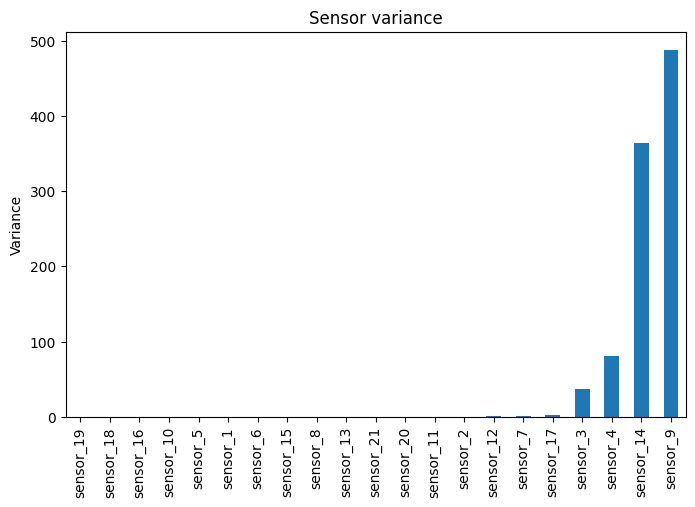

In [22]:
variance_df.plot(kind="bar")

plt.title("Sensor variance")
plt.ylabel("Variance")

plt.show()

For a better view we apply the log scale for the y-axes

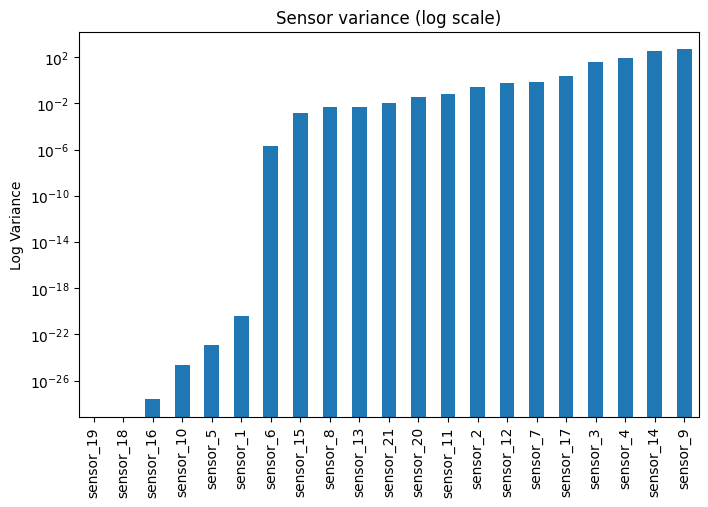

In [23]:
variance_df.plot(kind="bar", logy=True)

plt.title("Sensor variance (log scale)")
plt.ylabel("Log Variance")

plt.show()

In [24]:
low_variance_sensors = variance_df[variance_df < 1e-2]

print(low_variance_sensors)

sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    2.422479e-28
sensor_10    2.172333e-25
sensor_5     1.152399e-23
sensor_1     4.273435e-21
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
dtype: float64


**Observations**:
- Several sensors exhibit near-zero variance
- These sensors are likely uninformative for predictive modeling
- Variance distribution spans multiple orders of magnitude

For this reason, these sensors could be removed during preprocessing.

### Cycle consistency

Verify that engine cycles start correctly.

In [25]:
df.groupby("engine_id")["cycle"].min().value_counts()

,count
cycle,
1,100


## Data Quality Summary
Observations:
- no missing values detected
- no duplicate rows detected
- all engines start from cycle 1
- several sensors show very low variance

Implications:
- low-variance sensors may be removed during preprocessing
- no imputation strategy is currently required

## Dataset overview

Understand how many engines and cycles are available.

In [26]:
print("Number of engines:", df["engine_id"].nunique())

Number of engines: 100


In [27]:
df.groupby("engine_id")["cycle"].max().describe()

,cycle
count,100.000000
mean,206.310000
std,46.342749
min,128.000000
25%,177.000000
50%,199.000000
75%,229.250000
max,362.000000


## Sensor behavior over time

Visualize sensor degradation for a single engine.

In [28]:
selected_sensors = ["sensor_2",
                    "sensor_7",
                    "sensor_11",
                    "sensor_12"]

In [29]:
engine = 1
subset = df[df["engine_id"] == engine]

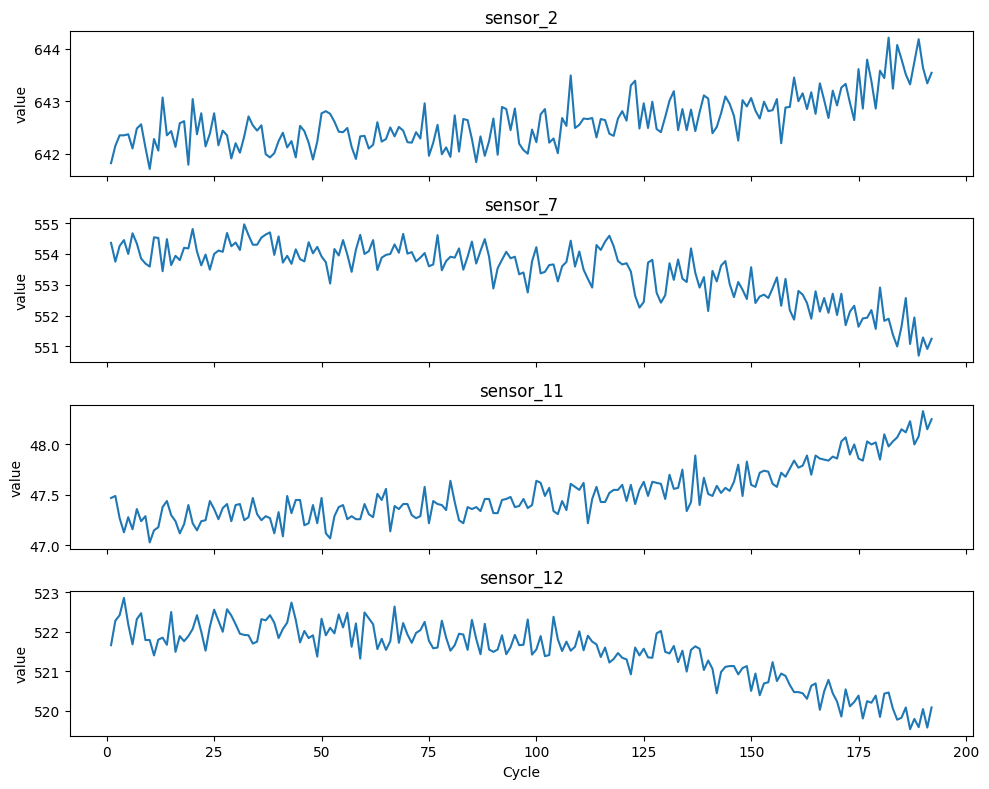

In [30]:
fig, axes = plt.subplots(len(selected_sensors), 1, figsize=(10, 8), sharex=True)

for i, sensor in enumerate(selected_sensors):
    axes[i].plot(subset["cycle"], subset[sensor])
    axes[i].set_title(sensor)
    axes[i].set_ylabel("value")

plt.xlabel("Cycle")
plt.tight_layout()
plt.show()

**Observations**:
- Some sensors show smoother degradation trajectories
- Others remain relatively stable over time
- Temporal dynamics differ significantly across sensors

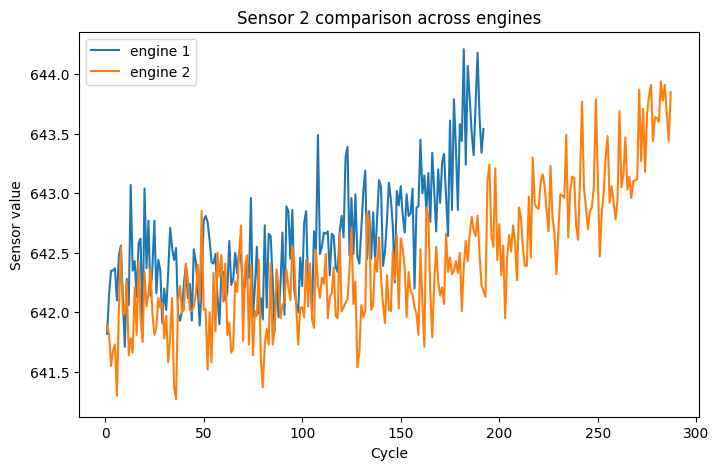

In [31]:
engine_1 = df[df["engine_id"] == 1]
engine_2 = df[df["engine_id"] == 2]

plt.plot(engine_1["cycle"], engine_1["sensor_2"], label="engine 1")
plt.plot(engine_2["cycle"], engine_2["sensor_2"], label="engine 2")

plt.legend()
plt.title("Sensor 2 comparison across engines")
plt.xlabel("Cycle")
plt.ylabel("Sensor value")

plt.show()

**Observations**:
- Sensor trajectories vary across engines
- Degradation is not identical between units
- This suggests the presence of engine-specific operational behavior

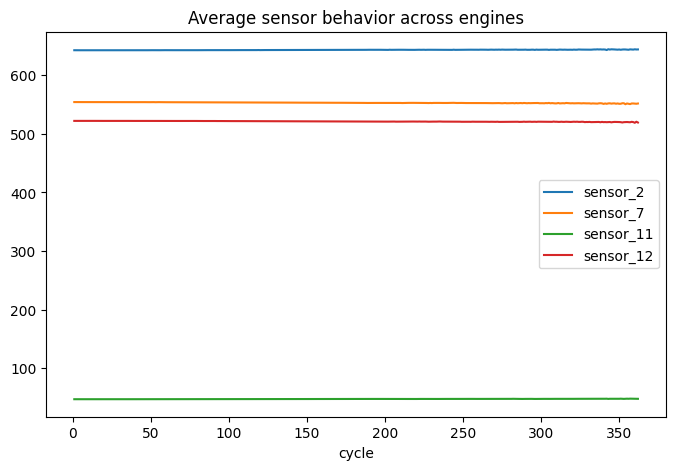

In [32]:
mean_sensor = df.groupby("cycle")[selected_sensors].mean()

mean_sensor.plot()
plt.title("Average sensor behavior across engines")
plt.show()

In [33]:
df.groupby("engine_id")[sensor_cols].mean().std().sort_values()

,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,5.247562e-17
sensor_10,1.801827e-15
sensor_5,2.861395e-14
sensor_1,1.142596e-12
sensor_6,2.375626e-04
sensor_15,1.425200e-02
sensor_21,4.076162e-02
sensor_8,4.111374e-02


**Observations**:
- Aggregated sensor trends reveal common degradation patterns
- Some sensors exhibit monotonic evolution across engine life
- Averaging reduces engine-specific noise

## Remaining Useful Life (RUL)

RUL is computed as:

\begin{aligned}
\text{max cycle for engine - current cycle}
\end{aligned}


In [34]:
max_cycle = (df.groupby("engine_id")["cycle"].max().reset_index())

max_cycle.columns = ["engine_id", "max_cycle"]

In [35]:
df = df.merge(max_cycle, on="engine_id")

In [36]:
df["RUL"] = df["max_cycle"] - df["cycle"]

In [37]:
df[["engine_id", "cycle", "RUL"]].head()

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


## RUL distribution

Analyze target distribution.

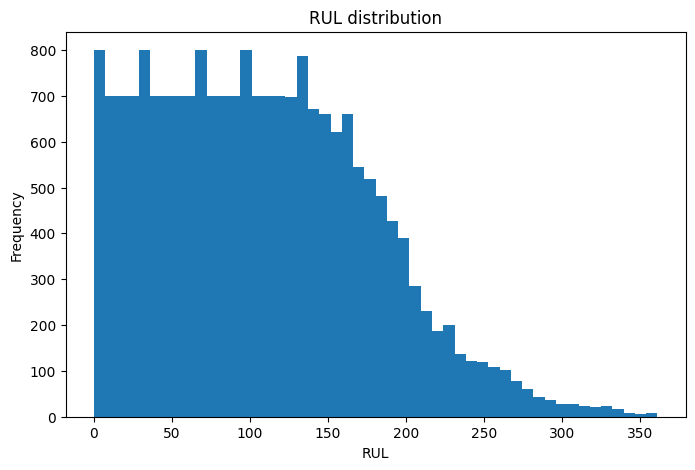

In [38]:
plt.hist(df["RUL"], bins=50)

plt.xlabel("RUL")
plt.ylabel("Frequency")
plt.title("RUL distribution")

plt.show()

**Observations**:
- RUL values are broadly distributed
- Lower RUL regions are densely populated
- The target distribution is not perfectly uniform

## Sensor-RUL analysis

In [39]:
df["life_phase"] = pd.qcut(df["RUL"], 3, labels=["late", "mid", "early"])
round(df.groupby("life_phase")[sensor_cols].mean().T, 2)

life_phase,late,mid,early
sensor_1,518.67,518.67,518.67
sensor_2,643.10,642.55,642.39
sensor_3,1595.53,1589.00,1587.01
sensor_4,1417.35,1406.48,1402.93
sensor_5,14.62,14.62,14.62
sensor_6,21.61,21.61,21.61
sensor_7,552.57,553.60,553.94
sensor_8,2388.15,2388.08,2388.06
sensor_9,9077.85,9060.65,9057.16
sensor_10,1.30,1.30,1.30


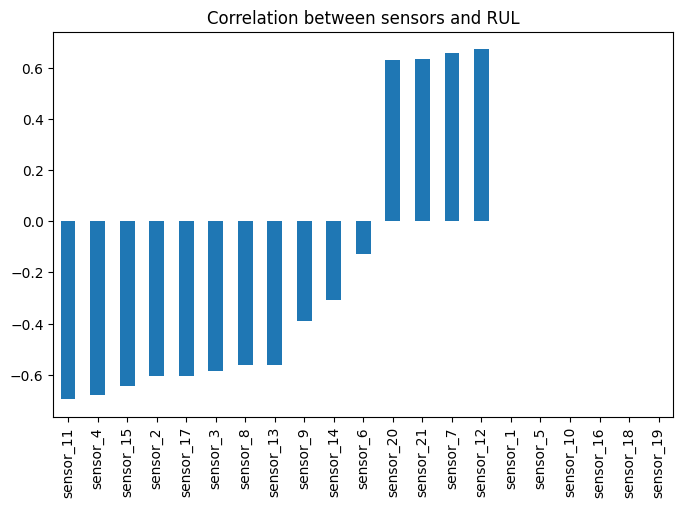

In [40]:
sensor_cols = [col for col in df.columns if "sensor" in col]
corr = df[sensor_cols + ["RUL"]].corr()["RUL"].sort_values()

corr.drop("RUL").plot(kind="bar")
plt.title("Correlation between sensors and RUL")
plt.show()

**Observations**:
- Several sensors show strong correlation with RUL
- Both positive and negative relationships are present
- Some sensors appear weakly informative and may be excluded

## Feature Selection Decisions

Based on EDA:
- remove low variance sensors
- keep sensors with high correlation to RUL
- avoid redundant sensors (high inter-correlation)

## EDA Summary
- Data Quality
  - Dataset is clean (no missing or duplicates)
- Sensor Behavior
  - Sensor behavior varies significantly across engines
  - Clear degradation patterns exist

- Predictive Signals
  - Some sensors show strong relationship with RUL

These findings will guide the preprocessing and feature engineering
pipeline implemented in the next notebook.

## Next steps:
- remove low-information sensors
- create rolling and lag features
- normalize per engine
- build forecasting models

## Save interim dataset

Save processed dataset for next stages.

In [41]:
df.to_parquet("../data/interim/train_fd001_eda.parquet", index=False)